# Text Summarization Agent

The goal is to shorten a long text into a few sentences that keep its main points. The data are Wikipedia articles about human rights (106 articles collected and stored in `articles/`). A Wikipedia article starts with a short introduction that summarizes the article, written by people; here that introduction is used as the reference summary and the rest of the article is the text to summarize.

Reference solution: [Text Summarization with Python](https://amanxai.com/2020/12/31/text-summarization-with-python/) (Thecleverprogrammer). It is an extractive summarizer written by hand: it counts how often each word appears, scores each sentence by the sum of the frequencies of its words, and prints the best sentences. It has no data and no evaluation: the text to summarize is typed in a variable and the result is read by eye.

This notebook implements the reference, checks it against the human introductions with the ROUGE score, compares it with a corrected version, with a graph-based method (TextRank), with the first sentences of the text, with a local language model (Llama 3.2, run by Ollama, no API key needed) and with a small agent that combines an extraction tool and the language model. The texts are from Wikipedia (CC BY-SA licence).

In [3]:
#pip install networkx

In [7]:
#pip install rouge_score

In [8]:
import re
import glob
import json
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import nltk
import matplotlib.pyplot as plt

from heapq import nlargest
from nltk.corpus import stopwords
from rouge_score import rouge_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/AI Agents/text_summarization_agent')

for resource in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(resource, quiet=True)
stop_words = set(stopwords.words("english"))

## Data Loading

In [9]:
articles = {os.path.basename(f)[:-4].replace("_", " "): open(f, encoding="utf-8").read() for f in sorted(glob.glob("articles/*.txt"))}
print("articles:", len(articles), "| median length:", int(np.median([len(t) for t in articles.values()])), "characters")
next(iter(articles.values()))[:400]

articles: 106 | median length: 14694 characters


'The American Convention on Human Rights (ACHR), also known as the Pact of San José or by its Spanish name used in most of the signatory nations, Convención Americana sobre Derechos Humanos, is an international human rights instrument. It was adopted by many countries in the Americas in San José, Costa Rica, on 22 November 1969. It came into force after the eleventh instrument of ratification (that'

## Data Preparation

Each article is cut at its first section heading (`== ... ==`): the text before it is the introduction (the reference summary) and the rest, with the headings removed, is the text to summarize. Articles are kept if the introduction has 300 to 1,500 characters and the rest at least 3,000 characters (some articles are empty or very short). To keep the language model fast on a CPU, only the first 5,000 characters of the text (about 800 words) are used, the same for every method. 30 articles are drawn at random.

In [10]:
def split_article(text):
    position = text.find("\n==")
    lead = text[:position].strip() if position > 0 else ""
    body = re.sub(r"^=+.*?=+\s*$", "", text[position:], flags=re.M)
    return re.sub(r"\s+", " ", lead), re.sub(r"\s+", " ", body).strip()[:5000] if position > 0 else ""

prepared = {name: split_article(text) for name, text in articles.items()}
usable = {name: pair for name, pair in prepared.items() if 300 <= len(pair[0]) <= 1500 and len(pair[1]) >= 3000}
sample = {name: usable[name] for name in np.random.default_rng(42).choice(sorted(usable), size=30, replace=False)}
print("usable articles:", len(usable), "| sampled:", len(sample))
print("reference summary: median", int(np.median([len(l.split()) for l, _ in sample.values()])), "words | text: median", int(np.median([len(b.split()) for _, b in sample.values()])), "words")

usable articles: 58 | sampled: 30
reference summary: median 146 words | text: median 780 words


## Reference Reproduction

The summarizer of the reference is written as a function, exactly as in the article (the number of sentences is a parameter here, because the reference chooses it from the length of the text). Two details of its code are checked afterwards: it counts the words with their capital letters (`word_freq` is built from the text as it is), but the sentences are lower-cased before the words are looked up, and it returns the sentences in the order of their score.

In [11]:
def reference_summary(text, length=3):
    no_punctuation = "".join(char for char in text if char not in ".,;:!?\"'()[]{}-")
    processed = [word for word in no_punctuation.split() if word.lower() not in stop_words]
    word_freq = {}
    for word in processed:
        word_freq[word] = word_freq.get(word, 0) + 1
    max_freq = max(word_freq.values())
    word_freq = {word: freq / max_freq for word, freq in word_freq.items()}
    sentence_score = {}
    for sentence in nltk.sent_tokenize(text):
        for word in nltk.word_tokenize(sentence.lower()):
            if word in word_freq:
                sentence_score[sentence] = sentence_score.get(sentence, 0) + word_freq[word]
    return " ".join(nlargest(length, sentence_score, key=sentence_score.get))

name = next(iter(sample))
words_with_capitals = [w for w in set(sample[name][1].split()) if w.lower() not in stop_words and w != w.lower()]
print("distinct words of the first text that contain a capital letter (they can never be found by the lower-case search):", len(words_with_capitals), "of", len({w for w in sample[name][1].split() if w.lower() not in stop_words}))

distinct words of the first text that contain a capital letter (they can never be found by the lower-case search): 78 of 359


The reference is reproduced as written. In the example above, 78 of the 359 distinct content words of the first text contain a capital letter (names, sentence starts). The frequencies are stored with their capitals, but the sentences are lower-cased before the lookup, so none of these words is ever found: the names, which are often the most informative words of an encyclopedia text, do not count in the sentence scores. The score is also a sum, so it favours long sentences, and the selected sentences are returned in the order of their score and not of the text, which breaks the flow of the summary.

## The Summarizers

All the methods return three sentences (or a summary of about three sentences for the language model).

- **First 3 sentences:** the beginning of the text.
- **Reference:** the method above.
- **Frequency, corrected:** the same idea with lower-case words, the sentences scored by the mean frequency of their words (so that long sentences are not favoured) and returned in the order of the text.
- **TextRank:** the sentences are the nodes of a graph, linked by the cosine similarity of their TF-IDF vectors; the three sentences with the highest PageRank are returned in the order of the text.
- **Language model:** Llama 3.2 asked to summarize the text in three sentences.
- **Agent (extraction + language model):** the TextRank tool selects the 8 most central sentences and the language model writes a three-sentence summary from them.

In [12]:
def sentences_of(text):
    return [s for s in nltk.sent_tokenize(text) if len(s.split()) >= 5]

def lead_summary(text, length=3):
    return " ".join(sentences_of(text)[:length])

def corrected_frequency_summary(text, length=3):
    words = [w for w in re.findall(r"[a-z]+", text.lower()) if w not in stop_words]
    freq = pd.Series(words).value_counts()
    freq = freq / freq.max()
    sentences = sentences_of(text)
    scores = [np.mean([freq.get(w, 0) for w in re.findall(r"[a-z]+", s.lower()) if w not in stop_words] or [0]) for s in sentences]
    chosen = sorted(np.argsort(scores)[::-1][:length])
    return " ".join(sentences[i] for i in chosen)

def textrank_sentences(text, length=3):
    sentences = sentences_of(text)
    vectors = TfidfVectorizer(stop_words="english").fit_transform(sentences)
    graph = nx.from_numpy_array(cosine_similarity(vectors))
    ranks = nx.pagerank(graph)
    chosen = sorted(sorted(ranks, key=ranks.get, reverse=True)[:length])
    return [sentences[i] for i in chosen]

def textrank_summary(text, length=3):
    return " ".join(textrank_sentences(text, length))

In [13]:
import ollama

def ask_model(instruction, text):
    answer = ollama.chat(model="llama3.2", messages=[{"role": "user", "content": f"{instruction}\n\n{text}"}], options={"temperature": 0, "num_predict": 200}, keep_alive="30m")
    return re.sub(r"\s+", " ", answer["message"]["content"]).strip()

cache_file = "llm_summaries.json"
cache = json.load(open(cache_file, encoding="utf-8")) if os.path.exists(cache_file) else {}

for name, (lead, body) in sample.items():
    if name not in cache:
        start = time.time()
        full = ask_model("Summarize the following text in three sentences. Use only the information in the text. Answer with the summary only.", body)
        middle = time.time()
        hybrid = ask_model("Summarize the following sentences in three sentences. Use only the information in the text. Answer with the summary only.", " ".join(textrank_sentences(body, 8)))
        cache[name] = {"full": full, "hybrid": hybrid, "seconds_full": round(middle - start, 1), "seconds_hybrid": round(time.time() - middle, 1)}
        json.dump(cache, open(cache_file, "w", encoding="utf-8"))
print("language model summaries:", len(cache))

language model summaries: 30


## Evaluation

In [14]:
summaries = {
    "First 3 sentences": {n: lead_summary(b) for n, (l, b) in sample.items()},
    "Reference (frequency)": {n: reference_summary(b) for n, (l, b) in sample.items()},
    "Frequency, corrected": {n: corrected_frequency_summary(b) for n, (l, b) in sample.items()},
    "TextRank": {n: textrank_summary(b) for n, (l, b) in sample.items()},
    "Language model": {n: cache[n]["full"] for n in sample},
    "Agent (TextRank + language model)": {n: cache[n]["hybrid"] for n in sample},
}

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"])

def content_words(text):
    return {w for w in re.findall(r"[a-z]+", text.lower()) if w not in stop_words}

def evaluate(method):
    rows = [{**{k: v.fmeasure for k, v in scorer.score(sample[n][0], summary).items()}, "words": len(summary.split()),
             "new words (%)": 100 * len(content_words(summary) - content_words(sample[n][1])) / max(len(content_words(summary)), 1)} for n, summary in summaries[method].items()]
    return pd.DataFrame(rows).mean()

results = pd.DataFrame({method: evaluate(method) for method in summaries}).T
results.round(3)

,rouge1,rouge2,rougeL,words,new words (%)
First 3 sentences,0.287,0.076,0.176,81.833,0.000
Reference (frequency),0.320,0.080,0.179,136.400,0.000
"Frequency, corrected",0.269,0.087,0.169,56.467,0.000
TextRank,0.311,0.095,0.195,81.633,0.000
Language model,0.352,0.105,0.198,106.333,27.991
Agent (TextRank + language model),0.315,0.089,0.190,75.733,20.192


seconds per summary of the language model: 53.6 | agent: 27.1
summaries of the reference that are identical to the first 3 sentences: 0 of 30


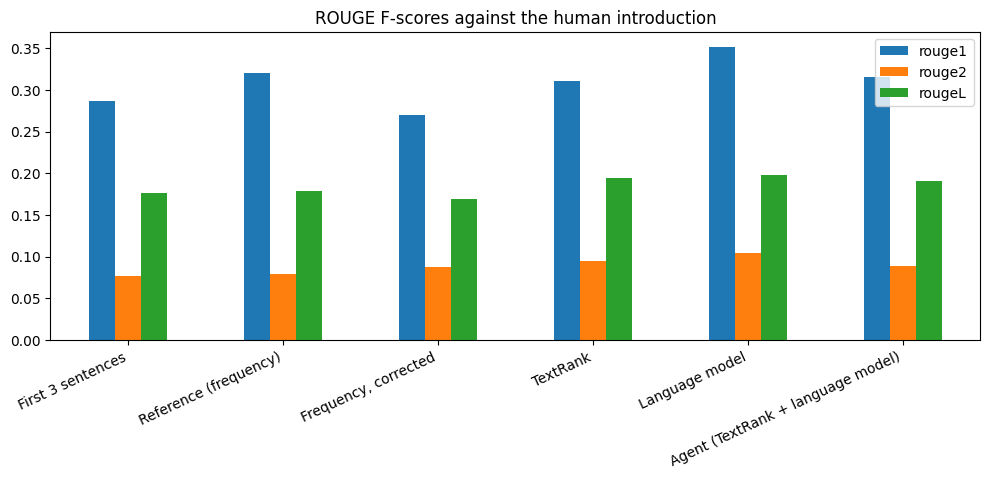

In [15]:
print("seconds per summary of the language model:", round(np.mean([v["seconds_full"] for v in cache.values()]), 1), "| agent:", round(np.mean([v["seconds_hybrid"] for v in cache.values()]), 1))
print("summaries of the reference that are identical to the first 3 sentences:", sum(summaries["Reference (frequency)"][n] == summaries["First 3 sentences"][n] for n in sample), "of", len(sample))
results[["rouge1", "rouge2", "rougeL"]].plot(kind="bar", figsize=(12, 4), title="ROUGE F-scores against the human introduction")
plt.xticks(rotation=25, ha="right"); plt.show()

ROUGE compares the words of a summary with the human introduction (ROUGE-1 counts single words, ROUGE-2 pairs of words, ROUGE-L the longest common sequence). Absolute values are low for every method (ROUGE-1 between 0.27 and 0.35), because the introduction is written by a person in different words and is about 146 words long against a summary of about 3 sentences. Only the differences matter, and with 30 articles they are only suggestive.

- The **language model** has the best scores on all three measures (ROUGE-1 0.352, ROUGE-2 0.105, ROUGE-L 0.198). It writes new sentences: 28% of its content words are not in the text, so its summaries need a check for invented facts, which ROUGE does not do.
- The **reference** has a high ROUGE-1 (0.320) but its summaries are long (136 words on average against 82 for the first sentences), and ROUGE-1 favours longer texts: it collects many words but its ROUGE-2 (0.080) is not better than the first three sentences (0.076), and its ROUGE-L (0.179) is the same as the first sentences (0.176). Longer sentences are the effect of the sum score.
- The **corrected frequency** method gives shorter summaries (56 words), and its F-scores are lower on ROUGE-1 (0.269) but its ROUGE-2 is higher than the reference (0.087). Its length is not the same as the others, so the comparison with them is not exact.
- **TextRank** has the best extractive scores on ROUGE-2 (0.095) and ROUGE-L (0.195) with the same length as the first three sentences (82 words). It is the best method that does not write new text.
- The **agent** (TextRank, then the language model) is between TextRank and the language model (ROUGE-1 0.315), with a shorter input for the model (8 sentences instead of 5,000 characters) and about half of the time of the full model. The answers of the model often start with a sentence such as "Here is a three-sentence summary of the text", which counts as a few wrong words.

The times per summary (in the cell above) were measured while other programs were also using the CPU, so only the ratio between the two model methods should be read, not the seconds.

One article as an example: the human introduction, and the summaries of the reference and of the agent.

In [16]:
example = list(sample)[3]
print(example)
for label, text in [("human introduction", sample[example][0]), ("reference", summaries["Reference (frequency)"][example]), ("agent", summaries["Agent (TextRank + language model)"][example])]:
    print(f"\n{label} ({len(text.split())} words):", text[:700])

Human rights in Greece

human introduction (49 words): Human rights in Greece are observed by various organizations. The country is a signatory to the European Convention on Human Rights, the Geneva Convention relating to the Status of Refugees and the United Nations Convention Against Torture. The Greek constitution also guarantees fundamental human rights to all Greek citizens.

reference (96 words): In response, police brutality has significantly increased, with consistent reports on the use of tear gas, severe injuries inflicted by the police force, and unjustified detention of protesters. The Greek Police, known officially as the Hellenic Police, assumed their current structure in 1984 as a result of merging the Gendarmerie (Chorofylaki) and the Urban Police Forces (Astynomia Poleon). Police allegedly sprayed protesters with chemical irritants from close range – in one instance a 17-year-old girl with asthma had been treated in the hospital after this attack and when she informed 

In this example the human introduction is a general description (which organizations observe human rights, which treaties are signed), but the text used as input is mostly about police behaviour, so all methods summarize what the text says and not what the introduction says. This is a limit of the evaluation: the introduction of an article is not always the summary of its first 5,000 characters, and a low ROUGE score can be the fault of the reference and not of the method.

## Conclusion

- The frequency summarizer of the reference has no evaluation. Compared with the introductions of 30 Wikipedia articles, it does not beat simply taking the first three sentences on ROUGE-2 and ROUGE-L, and it has three technical problems: capitalized words never match, long sentences are favoured by the sum, and the sentences are returned out of order.
- TextRank (TF-IDF cosine similarity and PageRank, with networkx) is the best method that only selects sentences from the text (ROUGE-2 0.095, ROUGE-L 0.195).
- The local language model (Llama 3.2, 3B) has the highest ROUGE scores (0.352 / 0.105 / 0.198), but it invents words that are not in the text (28% of its content words), and it is much slower than the extractive methods. The two-step agent (TextRank selects 8 sentences, the model rewrites them) halves the time for a lower score (ROUGE-1 0.315).
- The agent is a fixed workflow of two tools. Standard and well-documented tools were used (NLTK, scikit-learn, networkx, rouge-score).
- Limitations: 30 articles, one gold summary per article that is not always a summary of the input, ROUGE measures word overlap and not meaning or truth, and the language model outputs were generated once (temperature 0) and cached in `llm_summaries.json`. The Wikipedia texts are under the CC BY-SA licence.